## Plotting dx-dy correlation in the form of a jointplot

In [1]:
import hist
import json
import uproot
import numpy as np
import pandas as pd
import awkward_pandas
from hist import Hist
import seaborn as sns
import matplotlib.pyplot as plt
#pip install awkward-pandas

# Elastic

In [25]:
# Reading tree
infile = "/lustre24/expphy/volatile/halla/sbs/pdbforce/gmn_ana/pdout/nohcl_0p65zoff_elas_ana_data_sbs4_sbs50p_model1_pass2.root"
file = uproot.open(infile)
tree = file['Tout']
tdf = tree.arrays(library="pd")

In [26]:
# Lets first define cuts and bin info to preserve consistancy bet. data and MC analysis
#elcut = (tdf['W']>0.5) & (tdf['W']<1.15) & (tdf['eHCAL']>0.1) & tdf['bbfiduCut'] & (abs(tdf['coinT_ADC_c'])<1.34*3.5) #sbs14
elcut = tdf['WCut'] & (tdf['eHCAL']>0) & tdf['bbfiduCut'] & (abs(tdf['coinT_ADC_c'])<1.3*5) & tdf['SMCut']

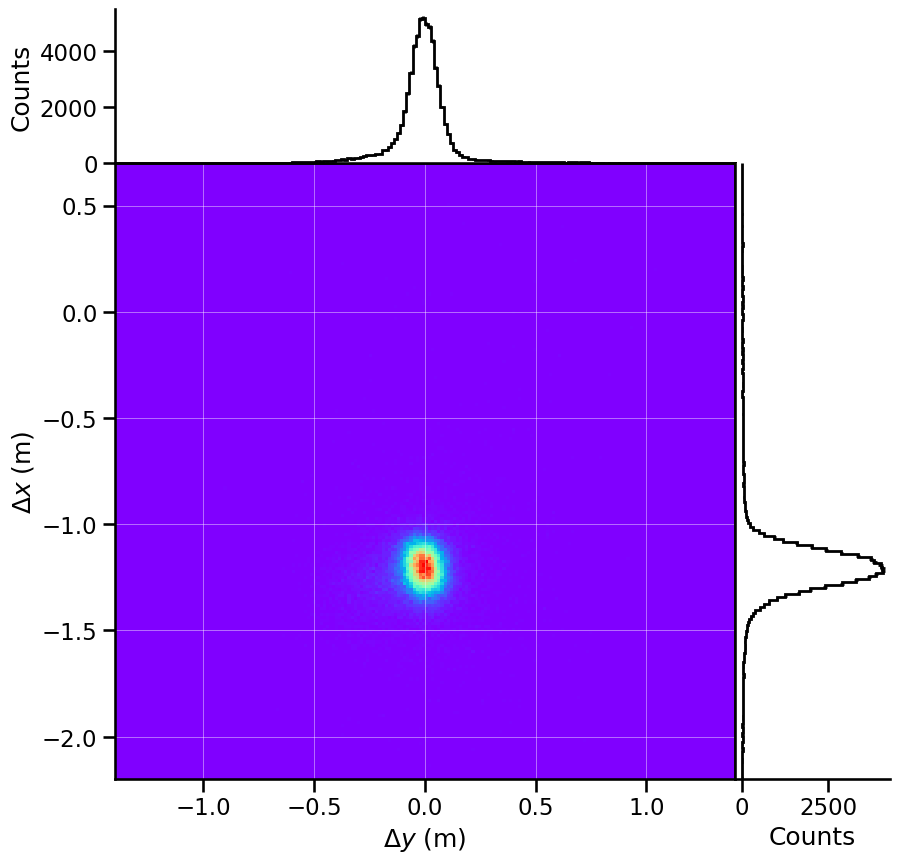

In [28]:
plt.style.use('default')
sns.set_context('talk')

plt.figure(figsize=(10, 10))

h_dxdy = Hist(
                hist.axis.Regular(200, -1.4, 1.4, name="dy", label=r'$\Delta y$ (m)', flow=False),
                hist.axis.Regular(200, -2.2, 0.7, name="dx", label=r'$\Delta x$ (m)', flow=False),
            )
h_dxdy.fill(tdf['dy'][elcut],tdf['dx'][elcut])

h_dxdy.plot2d_full(
    main_cmap="rainbow",
    top_ls="-",
    top_color="black",
    top_lw=2,
    side_ls="-",
    side_lw=2,
    side_color="black",
)

plt.grid(axis='both',color='white', linestyle='-', linewidth=0.5, alpha=0.6)
#plt.savefig('evselect_dxdy_elas_4.png')

plt.show()

# QE

In [2]:
# Reading tree
infile = "/lustre24/expphy/volatile/halla/sbs/pdbforce/gmn_ana/pdout/0p65zoff_qelas_ana_data_sbs4_sbs50p_model2_pass2.root"
file = uproot.open(infile)
tree = file['Tout']
tdf = tree.arrays(library="pd")

In [3]:
# Lets first define cuts and bin info to preserve consistancy bet. data and MC analysis
#elcut = (tdf['W']>0.5) & (tdf['W']<1.15) & (tdf['eHCAL']>0.1) & tdf['bbfiduCut'] & (abs(tdf['coinT_ADC_c'])<1.34*3.5) #sbs14
elcut = tdf['WCut'] & (tdf['eHCAL']>0) & tdf['bbfiduCut'] & (abs(tdf['coinT_ADC_c'])<1.3*5) & tdf['fiduCut']

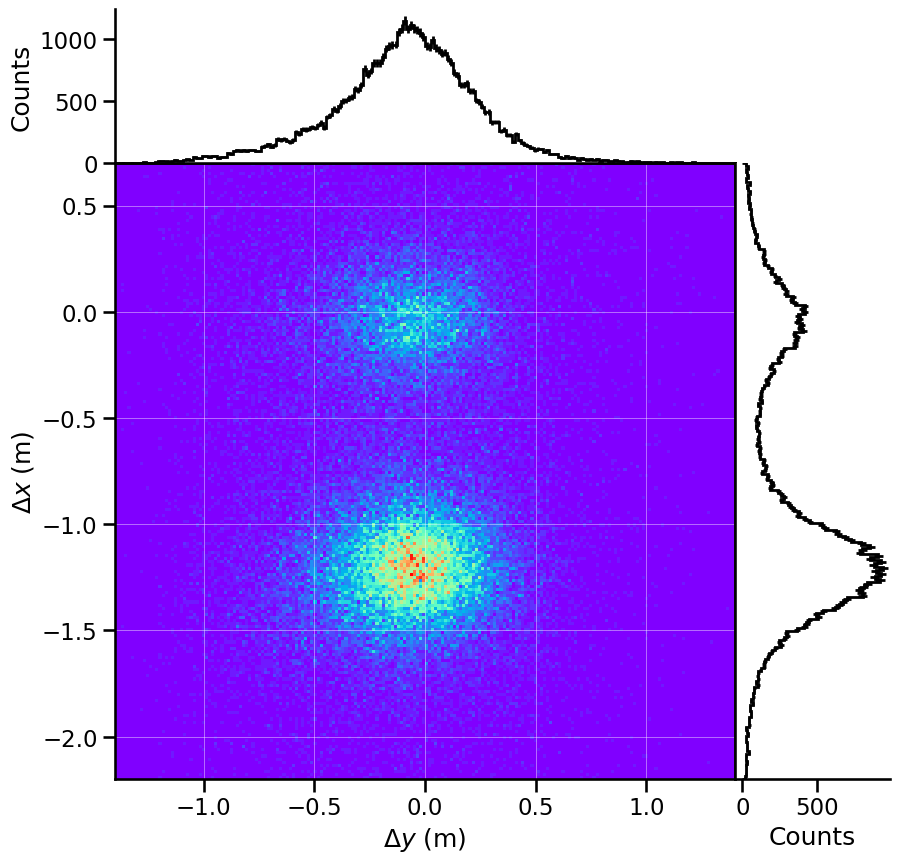

In [4]:
plt.style.use('default')
sns.set_context('talk')
#sns.set_style("whitegrid")

plt.figure(figsize=(10, 10))

h_dxdy = Hist(
                hist.axis.Regular(200, -1.4, 1.4, name="dy", label=r'$\Delta y$ (m)', flow=False),
                hist.axis.Regular(200, -2.2, 0.7, name="dx", label=r'$\Delta x$ (m)', flow=False),
            )
h_dxdy.fill(tdf['dy'][elcut],tdf['dx'][elcut])

h_dxdy.plot2d_full(
    main_cmap="rainbow",
    top_ls="-",
    top_color="black",
    top_lw=2,
    side_ls="-",
    side_lw=2,
    side_color="black",
)

plt.grid(axis='both',color='white', linestyle='-', linewidth=0.5, alpha=0.6)
#plt.savefig('evselect_dxdy_qelas_4.png')

plt.show()